Imports

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from adjustText import adjust_text
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

Constants and Global variables

In [2]:
INTERGENIC_TES_DISTANCES = "C:\\Users\\Ana\\Documents\\Estágio\\Sun2023\\TE_Intergenic_With_Distances.bed"
EXPRESSION_FILE = "C:\\Users\\Ana\\Documents\\Estágio\\Sun2023\\Expression_TE_DESeq.csv"
THRESHOLD_DISTANCE = 4000
CLINICAL_DATA = "C:\\Users\\Ana\\Documents\\Estágio\\Sun2023\\SraRunTable_Sun23.csv"

Histogram

  TE_Chr  TE_Start  TE_End          TE_Name  TE_Score TE_Strand   TE_Class-id  \
0   chr1     81232   81691  TE_Tigger5_dup1      2382         +  TcMar-Tigger   
1   chr1    197096  197166      TE_L2c_dup7       200         -            L2   
2   chr1    197313  197576    TE_AluSp_dup6      2050         +           Alu   
3   chr1    522955  523291  TE_AluSq2_dup17      1951         +           Alu   
4   chr1    524652  524930  TE_AluSx1_dup12      2085         +           Alu   

  TE_Family_id Gene_Chr  Gene_Start  Gene_End Gene_Name Gene_Score  \
0          DNA     chr1       65418     71585     OR4F5          .   
1         LINE     chr1      185216    195411    WASH9P          .   
2         SINE     chr1      182695    184174  DDX11L17          .   
3         SINE     chr1      487100    489906     CICP7          .   
4         SINE     chr1      487100    489906     CICP7          .   

  Gene_Strand  Distances  
0           +       9648  
1           -       1686  
2          

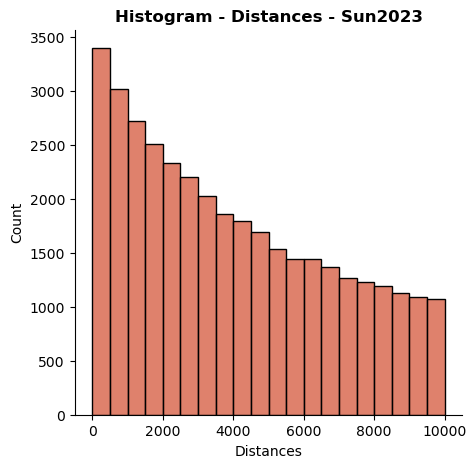

In [3]:
TEs_df = pd.read_csv(INTERGENIC_TES_DISTANCES, sep = '\t', header = None)
TEs_df.columns = ['TE_Chr', 'TE_Start', 'TE_End', 'TE_Name', 'TE_Score', 'TE_Strand', 'TE_Class-id', 'TE_Family_id',
                 'Gene_Chr', 'Gene_Start', 'Gene_End', 'Gene_Name', 'Gene_Score', 'Gene_Strand', 'Distances']

print(TEs_df.head())
def plot_histogram(df):
    fig, ax = plt.subplots(figsize = (5,5))

    final_df = df[df['Distances'] < 10000]

    sns.histplot(data = final_df, x = 'Distances', bins = 20, color = '#D5573B')

    ax.set_title('Histogram - Distances - Sun2023', fontweight = 'bold', fontsize = 12)
    sns.despine()
    plt.plot()
    get_count(ax)

def get_count(ax): # Alternativamente podia utilizar o numpy.histogram
    patches = ax.patches # Uma patch é um objeto gráfico 2D que representa uma forma geométrica (ou seja é tipo os pontos e as barras)
    bin_count = []
    bin_edges = []

    for patch in patches: # Só há 20 barras, há uma que não vai ficar nas edges
        bin_count.append(patch.get_height()) # Também podia ter feito bin_count = [patch for patch in patches], mas assim é mais eficiente
        bin_edges.append(patch.get_x())

    bin_width = patch.get_width()
    bin_edges.append(patches[-1].get_x() + bin_width) # Para conseguir a última edge

    hist_df = pd.DataFrame( {
                'Start' : bin_edges[:-1],
                'End' : bin_edges[1:],
                'Count' : bin_count
    }
    )
    print(hist_df)

plot_histogram(TEs_df)


PCA - Intergenics

In [4]:
# Read files
expr_df = pd.read_csv(EXPRESSION_FILE)
clinical_df = pd.read_csv(CLINICAL_DATA)

# Merge to get intergenic
expr_df = expr_df.rename(columns = {'Unnamed: 0' : 'TE_Name'})
TEs_df = TEs_df[['TE_Name']]
expr_df = expr_df.merge(TEs_df, on = 'TE_Name', how = 'inner')

# Organize and extract expression file
TEs_names = expr_df['TE_Name']
counts = expr_df.iloc[:, 1:]

# Organize clinical data
clinical_df = clinical_df[['Sample_Name', 'Run', 'Condition']]
print(clinical_df)

# Make log2cpm
library_size = counts.sum(axis = 0)
cpm_df = counts.div(library_size, axis = 1) * 1e6
log2cpm_df = np.log2(cpm_df + 1)


# Scaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(log2cpm_df.T)

# PCA
pca = PCA(n_components = 2)
pca_res = pca.fit_transform(scaled_data)

# Merge it all
pca_df = pd.DataFrame(pca_res, index = log2cpm_df.columns, columns = [f"PC{i+1}" for i in range(2)]) # Os nomes das amostras ficam como index e as colunas são as componentes principais
pca_df.reset_index(names = 'Sample_Name', inplace = True)
pca_df = pca_df.merge(clinical_df, on = 'Sample_Name', how = 'left')
pca_df.head()


  Sample_Name          Run    Condition
0     WT_rep1  SRR16497780           WT
1  MECP2_rep1  SRR16497781  MECP2_R270X
2     WT_rep2  SRR16497782           WT
3  MECP2_rep2  SRR16497783  MECP2_R270X
4     WT_rep3  SRR16497784           WT
5  MECP2_rep3  SRR16497785  MECP2_R270X


,Sample_Name,PC1,PC2,Run,Condition
0,WT_rep1,-390.951779,129.012318,SRR16497780,WT
1,MECP2_rep1,-55.785748,-328.688650,SRR16497781,MECP2_R270X
2,WT_rep2,113.206034,64.699074,SRR16497782,WT
3,MECP2_rep2,62.573423,-61.631137,SRR16497783,MECP2_R270X
4,WT_rep3,82.472992,79.464054,SRR16497784,WT


PCA - Graph

[]

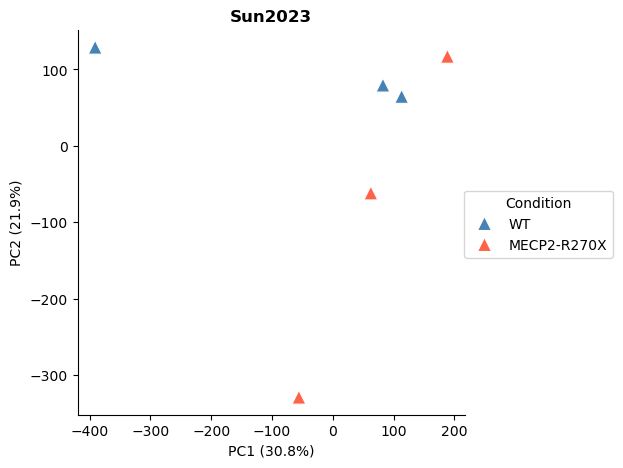

In [6]:
# Graph
fig, ax = plt.subplots(figsize = (5,5))

palette_pca = {
    'MECP2-R270X' : 'tomato',
    'WT' : 'steelblue'
}

pca_df['Condition'] = pca_df['Condition'].replace({'MECP2_R270X' : 'MECP2-R270X'})
sns.scatterplot(data = pca_df, x = 'PC1', y = 'PC2', palette = palette_pca, hue = 'Condition', s = 100, marker= '^')


# Labels
ax.set_title('Sun2023', fontweight = 'bold', fontsize = 12)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.legend(title = 'Condition', bbox_to_anchor = (1.4, 0.6))

sns.despine()
plt.plot()

